# Modelo com Rebalanceamento e Custos de Transação 

In [1]:
import pandas as pd
import numpy as np
import random
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.environ import SolverFactory
import yfinance as yf
from pathlib import Path
import os
import matplotlib.pyplot as plt


In [2]:
basedados_ativos = Path('../../base_dados/retornos_ativos_2015_2026.csv') 
basedados_ibov = Path('../../base_dados/retorno_ibov_2015_2026.csv') 

lista_magic_formula = []

for filename in os.listdir(path='../../base_dados/brapi/magic_formula/'):
    
    # 2. Reconstruct the full absolute or relative path to the file
    full_path = os.path.join('../../base_dados/brapi/magic_formula/', filename)
    
    # 3. Check if the current item is actually a file (and not a subfolder)
    # if os.path.isfile(full_path):
        
    #     # 4. Open and process the file safely
    #     with open(full_path, "r", encoding="utf-8") as file:
    #         content = file.read()
    #         print(f"--- Content of {filename} ---")
    #         print(pd.read_csv(full_path))
    dicio = {
        'ativo':filename,
        'data':pd.read_csv(full_path)
    }

    lista_magic_formula.append(dicio)

df_ativos=pd.read_csv(basedados_ativos).set_index(['Date']).fillna(0)

df_ibov=pd.read_csv(basedados_ibov).set_index(['Date']).dropna()



In [3]:
lista_ativos=[]
for ativo in df_ativos.columns.tolist():
    lista_ativos.append(ativo.replace('.SA',''))
    df_ativos.rename(columns={ativo:ativo.replace('.SA','')},inplace=True)

In [4]:
df_ativos.shape[0]

2857

In [5]:
print(f'tamanho mf original: ',len(lista_magic_formula))
lista_mf_check = []
lista_ativos_finais = []
for i in range(len(lista_magic_formula)):
    if lista_magic_formula[i]['ativo'] in lista_ativos:
        lista_ativos_finais.append(lista_magic_formula[i]['ativo'])
        dc = {
            'ativo':lista_magic_formula[i]['ativo'],
            'data':lista_magic_formula[i]['data']
        }
        lista_mf_check.append(dc)
    else:
        print(f"Nao está na lista: {lista_magic_formula[i]['ativo']}")
print(f'tamanho mf Final: ',len(lista_mf_check))
        

tamanho mf original:  69
tamanho mf Final:  69


In [7]:
df_ativos = df_ativos.filter(lista_ativos_finais)

In [21]:
df_ativos_t_2025 = df_ativos[:-121]
df_plot_2026=df_ativos[2736:]

In [22]:
print(df_ativos_t_2025.shape)
df_ativos_t_2025.tail()

(2736, 69)


,ABEV3,ALOS3,AXIA3,AZZA3,B3SA3,BBAS3,BBDC3,BBDC4,BBSE3,BEEF3,...,SUZB3,TAEE11,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3,YDUQ3
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-22,-0.012048,-0.011821,-0.225318,0.007958,-0.011202,-0.006530,-0.010088,-0.014054,-0.005671,-0.007055,...,-0.002338,-0.013943,-0.020483,-0.007285,0.003413,0.029217,0.000403,-0.010969,-0.016945,-0.032362
2025-12-23,0.026677,0.026297,0.026721,0.017949,0.021903,0.021127,0.009554,0.009320,0.013687,0.012433,...,0.005859,0.011412,0.004934,0.023973,0.003401,-0.000274,0.016103,0.003697,0.013009,0.048495
2025-12-26,0.018560,0.006406,-0.001401,0.026868,0.014043,0.004598,0.000631,-0.000543,0.006188,0.003509,...,0.003495,0.014471,-0.009119,-0.003344,0.003390,0.003018,0.000396,0.013505,0.009735,0.001595
2025-12-29,0.010933,-0.006011,0.000401,0.014718,0.005102,-0.005950,-0.000630,0.004891,0.008387,0.010490,...,-0.002516,0.003143,-0.013686,-0.000479,0.001689,-0.013676,-0.002376,0.000606,-0.000821,0.005766
2025-12-30,-0.000721,0.009249,0.014228,0.013699,0.007252,0.009208,0.006529,0.004768,0.002218,-0.003460,...,-0.001940,0.014943,0.006699,0.002398,0.003373,-0.002219,0.005558,0.005148,-0.004106,0.009121


In [47]:
dfibov_t_2025 = df_ibov[:-121]
df_ibov_2026 = df_ibov[2728:]

In [49]:
dfibov_t_2025.tail()

,IBOV
Date,
2025-12-22,-0.002089
2025-12-23,0.014632
2025-12-26,0.002748
2025-12-29,-0.002530
2025-12-30,0.003957


In [43]:
df_plot_2026.tail()

,ABEV3,ALOS3,AXIA3,AZZA3,B3SA3,BBAS3,BBDC3,BBDC4,BBSE3,BEEF3,...,SUZB3,TAEE11,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3,YDUQ3
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-23,0.015187,0.003798,0.025922,0.036083,0.001361,0.014300,0.007129,0.009050,-0.009319,0.020000,...,-0.002141,-0.003256,0.011009,0.010706,-0.049396,-0.018910,0.015782,0.022063,0.010166,0.009467
2026-06-24,0.000611,0.004083,-0.000738,-0.039304,0.021060,-0.006546,-0.010296,-0.010650,0.010713,0.000000,...,0.005959,-0.001759,-0.005082,-0.006669,0.002310,-0.020786,-0.009527,-0.000875,0.019689,0.029308
2026-06-25,0.000611,0.023660,0.016242,0.025375,-0.013426,0.016219,-0.001300,-0.001700,0.004912,-0.014006,...,-0.004739,0.004028,-0.009121,-0.002765,-0.020737,0.011964,0.002061,0.009343,-0.002360,-0.003417
2026-06-26,0.020744,0.012640,0.010171,-0.040909,0.021218,0.014464,0.018229,0.017026,0.007718,0.019886,...,-0.045000,-0.004012,0.056333,0.013861,-0.027059,-0.006484,0.017827,0.006364,0.008602,0.017143
2026-06-29,-0.008368,0.000713,-0.009169,-0.032122,-0.014075,-0.003933,0.010870,0.013951,0.004085,0.030641,...,-0.010721,0.010070,-0.006623,0.028125,0.007255,-0.000256,0.007747,-0.009160,-0.002345,-0.004494


In [26]:
lista_scores_ativos = []
i=0
anos = ['2025-12-31',
 '2024-12-31',
 '2023-12-31',
 '2022-12-31',
 '2021-12-31',
 '2020-12-31',
 '2019-12-31',
 '2018-12-31',
 '2017-12-31',
 '2016-12-31',
 '2015-12-31',
 ]


dict_score = {}

for i, ativo in enumerate(df_ativos_t_2025.columns.tolist()):
    if ativo == lista_mf_check[i]['ativo']:
        for ano in anos:
            df_temp = lista_mf_check[i]['data'].query("endDate in @ano")
            score_anual = (0.5*df_temp['ROC'] + 0.5*df_temp['EY']).sum()
            dict_score[(ano, ativo)] = score_anual

    else:
        print(f" ativo: {ativo}")
        print(f" ativo_mf: {lista_mf_check[i]['ativo']}")
df_scores = pd.Series(dict_score).unstack()  # index=anos, columns=ativos
df_scores = df_scores.replace([np.inf, -np.inf],0)


In [28]:
df_scores

,ABEV3,ALOS3,AXIA3,AZZA3,B3SA3,BBAS3,BBDC3,BBDC4,BBSE3,BEEF3,...,SUZB3,TAEE11,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3,YDUQ3
2015-12-31,0.594862,0.000000,-0.280358,0.188981,0.657607,0.0,0.0,0.0,-9.966455,0.180942,...,0.122797,0.778584,0.244284,0.206290,-0.293338,-0.134539,0.000000,0.182352,0.125224,0.000000
2016-12-31,0.647566,0.000000,0.437653,0.182051,0.159373,0.0,0.0,0.0,8.300923,0.165886,...,0.057763,0.817620,0.270700,0.191239,-0.015953,0.117405,0.000000,0.216678,0.122047,0.000000
2017-12-31,0.587594,0.000000,0.102611,0.176699,0.516373,0.0,0.0,0.0,0.762433,0.132496,...,0.137881,0.386604,0.156448,0.155287,0.053717,0.157766,0.000000,0.201579,0.105024,0.000000
2018-12-31,0.458825,0.000000,0.290077,0.167959,0.582628,0.0,0.0,0.0,0.840080,0.101767,...,0.102232,0.594479,0.162956,0.083231,0.070120,0.186096,0.000000,0.269189,0.137534,0.000000
2019-12-31,0.355483,0.000000,0.123206,0.159262,0.592116,0.0,0.0,0.0,6.092117,0.182507,...,0.036793,0.299155,0.111942,0.051649,0.057853,0.009492,0.000000,0.155319,0.128438,0.210200
2020-12-31,0.341938,0.000000,0.120880,0.231086,0.368439,0.0,0.0,0.0,1.935121,0.190148,...,0.107585,1.064734,0.183543,0.073868,0.158053,0.160388,0.000000,0.139533,0.131848,0.059925
2021-12-31,0.337624,0.000000,0.186489,0.472033,0.401957,0.0,0.0,0.0,1.439823,0.176514,...,0.200900,2.189265,0.115833,0.076347,0.541693,0.425030,0.118572,0.144723,0.170240,0.102958
2022-12-31,0.369856,0.000000,0.086395,0.227299,0.357122,0.0,0.0,0.0,2.625364,0.204337,...,0.225507,0.571417,0.116902,0.203470,0.162331,0.283103,0.165976,0.135872,0.177991,0.129153
2023-12-31,0.470778,1.655507,0.155706,0.224497,0.372106,0.0,0.0,0.0,9.861037,0.148201,...,0.125583,0.615600,0.136359,0.212051,0.045923,0.199971,0.296632,0.142912,0.205852,0.161215
2024-12-31,0.382615,0.390018,0.220927,0.062188,0.476487,0.0,0.0,0.0,3.085574,0.136335,...,0.143495,1.861961,0.244373,0.258414,0.036779,0.180815,0.328907,0.137659,0.195430,0.190485


In [52]:
vb_cardinalidade_max = 30
vb_cardinalidade_min = 10
vb_peso_maximo = 0.15
vb_peso_minimo = 0.02
vb_theta = 3

# Modelo com dados fundamentalistas

In [53]:
# ------ CRIAÇÃO DO MODELO
model = pyo.ConcreteModel()

#variavel x para peso, y para cardinalidade

#--------------------
model.nome_ativos = pyo.Set(initialize = lista_ativos_finais)
model.ativos = pyo.RangeSet(0, len(lista_ativos_finais)-1)
model.dias = pyo.RangeSet(0, len(df_ativos_t_2025)-1)
model.anos = pyo.RangeSet(0, len(anos)-1)
model.nome_anos = pyo.Set(anos)
model.retornos_ativos = pyo.Param(model.dias, model.ativos, initialize=lambda model,dia, ativo: df_ativos_t_2025.iloc[dia, ativo])    
# model.retornos_ibov = pyo.Param(model.dias, initialize=lambda model,dia: dados_retorno_2024['IBOV'].iloc[dia])
model.theta = pyo.Param(initialize=vb_theta)

#Scores
# model.score_2015 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[0,ativo])
# model.score_2016 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[1,ativo])
# model.score_2017 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[2,ativo])
# model.score_2018 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[3,ativo])
# model.score_2019 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[4,ativo])
# model.score_2020 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[5,ativo])
# model.score_2021 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[6,ativo])
# model.score_2022 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[7,ativo])
# model.score_2023 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[8,ativo])
# model.score_2024 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[9,ativo])
# model.score_2025 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[10,ativo])
model.score = pyo.Param(
    model.anos, model.ativos,
    initialize=lambda model, t, a: df_scores.iloc[t, a]
)
model.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model.peso_minimo = pyo.Param(initialize=vb_peso_minimo)

model.x = pyo.Var(model.ativos, bounds=(0,1))
model.y = pyo.Var(model.ativos, within=pyo.Binary)

# Teste, tentar fazer o modelo descobrir melhor quantidade de ativos na carteira.
model.card_valor = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(vb_cardinalidade_min, vb_cardinalidade_max))

model.peso_ano = pyo.Param(model.anos,initialize={0:0.05, 1:0.05, 2:0.05, 3:0.07, 4:0.08,5:0.10, 6:0.10, 7:0.12, 8:0.13, 9:0.13, 10:0.12}
)


def func_objetivo_1(model):
    retorno_esperado = sum(
        sum(model.retornos_ativos[dia, a] * model.x[a] for a in model.ativos)
        for dia in model.dias
    )

    score_total = model.theta * sum(
    model.x[a] * sum(model.peso_ano[t] * model.score[t, a] for t in model.anos) 
    for a in model.ativos
    )

    return retorno_esperado + score_total

model.obj1 = pyo.Objective(rule=func_objetivo_1, sense=pyo.maximize)

print('-----Model COnstruído-----')


#REstricao 1 x só ativa se y = 1
def restr_vinculo_x_y(model, a):
    return model.x[a] <= model.y[a]
model.const_restr_vinculo_x_y = pyo.Constraint(model.ativos, rule=restr_vinculo_x_y)

#peso maximo por acao
def rule_peso_maximo(model, a):
    # return model.x[a] <= 1/model.cardinalidade_valor
    return model.x[a] <= model.peso_maximo

model.const_peso_maximo = pyo.Constraint(model.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model, a):
    return model.x[a] >= model.peso_minimo * model.y[a]  # se y=1, então x >= 0.05
model.const_peso_minimo = pyo.Constraint(model.ativos, rule=rule_peso_minimo)

#Restrição 2 soma peso 1
def soma_peso_1(model):
    return sum(model.x[a] for a in model.ativos) == 1
model.const_soma_peso_1 = pyo.Constraint(rule=soma_peso_1)

# Restrição 3 de cardinalidade, quantidade de ativos no total
def cardinalidade_max(model):
    return sum(
        model.y[a] for a in model.ativos
        ) <= model.cardinalidade_valor_max
model.const_cardinalidade_total_max = pyo.Constraint(rule=cardinalidade_max)

def cardinalidade_min(model):
    return sum(
        model.y[a] for a in model.ativos
        ) >= model.cardinalidade_valor_min
model.const_cardinalidade_total_min = pyo.Constraint(rule=cardinalidade_min)




opt = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
# opt = SolverFactory('cplex', executable='C:\\Program Files\\IBM\\ILOG\\CPLEX_Studio_Community222\\cplex\\bin\\x64_win64\\cplex.exe')
# opt.options['TimeLimit'] = 60
resultado = opt.solve(model, tee=True)
print("-------FIM----------")

-----Model COnstruído-----

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmpswccdv_k.cplex.log' open.
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmp8jyqabt5.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmp8jyqabt5.pyomo.lp
Objective sense      : Maximize
Variables            :     138  [Box: 69,  Binary: 69]
Objective nonzeros   :      69
Linear constraints   :     210  [Less: 208,  Greater: 1,  Equal: 1]
  Nonzeros           :     552
  RHS nonzeros       :      72

Variables            : Min LB: 0.000000         Max UB: 1.00000

In [46]:
# model.pprint()

## MOSTRANDO RESULTADO DA 1 PRIMEIRA PARTE

In [54]:
lista_grande = []
for numero in range(len(df_ativos_t_2025.columns)):
    peso_ativo = pyo.value(model.x[numero])
    ativado = pyo.value(model.y[numero])
    
    lista = [peso_ativo, ativado]
    lista_grande.append(lista)
print(lista_grande)
print(f'cardinalidade min: {vb_cardinalidade_min}')
print(f'cardinalidade max: {vb_cardinalidade_max}')
# print('cardinalidade escolhida: ',pyo.value(model.card_valor))

final = pd.DataFrame(lista_grande, columns=["peso_ativo","ativado"], index=df_ativos_t_2025.columns)
print(f' quantidade de ativos escolhidos: ',len(final[final['ativado']!=0]))
print(final[final['ativado']!=0])

[[0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.02, 1.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, -0.0], [0.02, 1.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.02, 1.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.15000000000000002, 1.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.039999999999999813, 1.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.15000000000000002, 1.0], [0.0, -0.0], [0.0, 0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0]]
cardinalidade min: 10
card

        peso_ativo  ativado
BBSE3         0.15      1.0
BRAP4         0.15      1.0
CMIG4         0.15      1.0
CSMG3         0.02      1.0
CXSE3         0.15      1.0
ISAE4         0.02      1.0
MULT3         0.02      1.0
PRIO3         0.15      1.0
SBSP3         0.04      1.0
TAEE11        0.15      1.0
114.94668514798738


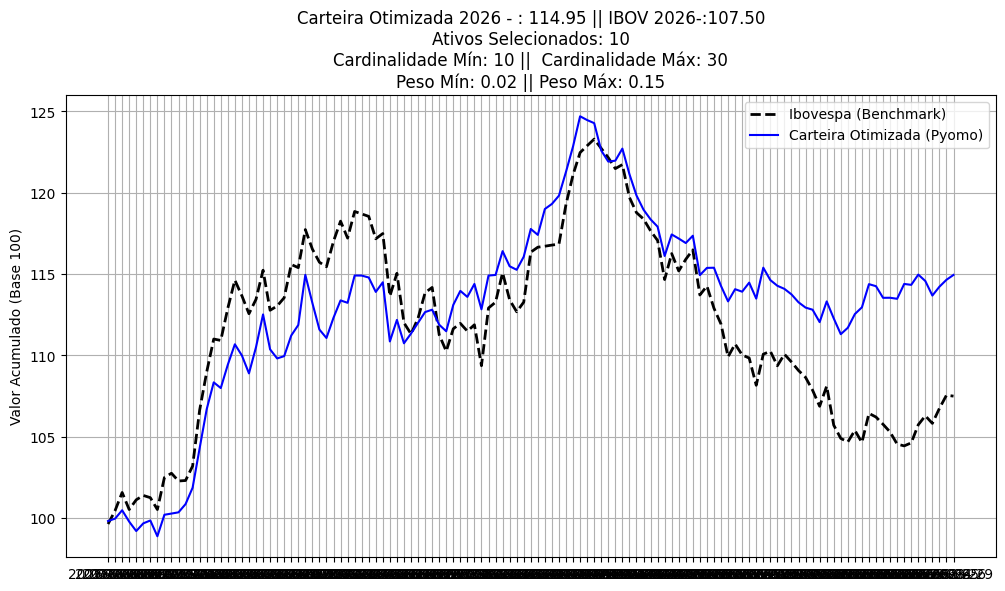

In [63]:
df_final = final[final['ativado']!=0]
print(df_final.head(20))
ativos_selecionados = df_final.index
retornos_carteira= df_plot_2026[ativos_selecionados]
# print(retornos_carteira)
carteira_otimizada = (retornos_carteira*df_final['peso_ativo']).sum(axis=1)
carteira_otimizada = 1 + carteira_otimizada
# print(carteira_otimizada)
# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado = (carteira_otimizada).cumprod() * 100

# acum_equi = (carteira_equi).cumprod() * 100
acum_ibov = (1 + df_ibov_2026['IBOV']).cumprod() * 100

print(acum_otimizado.tail(1).values[0])
# print(acum_otimizado[-1])
# print(acum_equi[-1])
# print(acum_ibov[-1])

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado, label='Carteira Otimizada (Pyomo)', color='blue')
# plt.plot(acum_equi, label='Carteira Equiponderada', color='red', alpha=0.5)

texto = f"Carteira Otimizada 2026 - : {acum_otimizado.tail(1).values[0]:.2f} || IBOV 2026-:{acum_ibov.tail(1).values[0]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}\nCardinalidade Mín: {vb_cardinalidade_min} ||  Cardinalidade Máx: {vb_cardinalidade_max}\nPeso Mín: {vb_peso_minimo} || Peso Máx: {vb_peso_maximo}"
# plt.title('Comparação de Performance: Index Tracking (10 ativos)')
plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()

### -------- 2º parte -  REBALANCEAMENTO

In [12]:
pesos_anteriores = {a: pyo.value(model.x[a]) for a in model.ativos}
pesos_anteriores

{0: 0.0,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.0,
 5: 0.0,
 6: 0.0,
 7: 0.0,
 8: 0.0,
 9: 0.12000000000000002,
 10: 0.0,
 11: 0.12000000000000002,
 12: 0.0,
 13: 0.0,
 14: 0.0,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.12000000000000002,
 19: 0.12000000000000002,
 20: 0.0,
 21: 0.0,
 22: 0.0,
 23: 0.0,
 24: 0.0,
 25: 0.0,
 26: 0.0,
 27: 0.0,
 28: 0.0,
 29: 0.0,
 30: 0.03999999999999998,
 31: 0.0,
 32: 0.0,
 33: 0.0,
 34: 0.0,
 35: 0.12000000000000002,
 36: 0.0,
 37: 0.12000000000000002,
 38: 0.0,
 39: 0.0,
 40: 0.0,
 41: 0.0,
 42: 0.0,
 43: 0.12000000000000002,
 44: 0.0,
 45: 0.0,
 46: 0.0,
 47: 0.0,
 48: 0.0,
 49: 0.0,
 50: 0.0,
 51: 0.0,
 52: 0.0,
 53: 0.0,
 54: 0.0,
 55: 0.0,
 56: 0.0,
 57: 0.0,
 58: 0.0,
 59: 0.0,
 60: 0.12000000000000002,
 61: 0.0}

In [13]:
score_2024_ativos = {}
i=0
for ticker in df_mf_2024['ticker'].unique():
    
    df_temp = df_mf_2024[df_mf_2024['ticker'] == ticker]
    # print(df_temp[['dt_refer', 'earnings_yield', 'ROIC']])
    score_anual = (0.5*df_temp['earnings_yield'] + 0.5*df_temp['ROIC']).sum()
    score_2024_ativos[i] = score_anual
    i=i+1

In [82]:
## a ideia aqui é Compra e Venda ,
## mas nao binária, ou seja, nao é 0 nao compra e 1 compra,
# é porcentagem, o quanto comprar e o quanto vender , envolvende uma custo de transação

#criando modelo novo
model_B = pyo.ConcreteModel()

model_B.ativos = pyo.RangeSet(0, len(dados_retorno_2025.columns)-1)
model_B.dias = pyo.RangeSet(0, len(dados_retorno_2025)-1)
model_B.ATIVOS_SEGUNDA_METADE = pyo.Param(model_B.dias, model_B.ativos,initialize=lambda model,dia, ativo: dados_retorno_2025.iloc[dia, ativo])
# model_B.IBOV_SEGUNDA_METADE = pyo.Param(model_B.dias, initialize = lambda model_B,dia: retornos_ibov_segunda_metade['IBOV'].iloc[dia])

#como se fosse o problema da lista de saber o Quanto a empresa deve produzir e o Quanto a empresa deve comprar o produto de outra

#Definindo variáveis de compra e venda, que serão as usadas
model_B.x = pyo.Var(model_B.ativos, bounds=(0,1)) #novos pesos 
model_B.y = pyo.Var(model_B.ativos, within=pyo.Binary) #nova cardinalidade 
model_B.compra =pyo.Var(model_B.ativos, bounds=(0,1))
model_B.venda =pyo.Var(model_B.ativos, bounds=(0,1))
custo_taxa = 0.0003 # = 0.03%


model_B.theta = pyo.Param(initialize=vb_theta)
model_B.score = pyo.Param(model_B.ativos, initialize=lambda model, ativo: score_2024_ativos[ativo])
model_B.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model_B.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model_B.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model_B.peso_minimo = pyo.Param(initialize=vb_peso_minimo)

#OBJETIVO
def func_objetivo_2(model_B):
    #como se trata de 2 momentos, o tracking e o custo de transação
    retorno_fundamentalista = sum((sum(model_B.ATIVOS_SEGUNDA_METADE[dia, ativo] * model_B.x[ativo] for ativo in model_B.ativos)) for dia in model_B.dias) + model_B.theta * sum(
        model_B.x[ativo]  * model_B.score[ativo] for ativo in model_B.ativos
    )
    
    score_total = model_B.theta * sum(model_B.x[a] * model_B.score[a]  for a in model_B.ativos)


    # Custo = taxa × (volume comprado + volume vendido)
    custo_transacao = sum(model_B.compra[ativo] + model_B.venda[ativo] for ativo in model_B.ativos) * custo_taxa

    return retorno_fundamentalista + score_total - custo_transacao
    # return retorno_fundamentalista

model_B.obj = pyo.Objective(rule=func_objetivo_2, sense=pyo.maximize)

#Restrições
#mais importante se a compra e venda será usada

def regra_equilibrio(model_B, ativo):
    return model_B.x[ativo] == pesos_anteriores[ativo] + model_B.compra[ativo] - model_B.venda[ativo]

model_B.regra_equilibrio = pyo.Constraint(model_B.ativos, rule=regra_equilibrio)

#restrições de soma peso 1 ; de x só ser ativado se y = 1 ; de cardinalidade 15 para y

def model_B_soma_peso_1(model_B):
    return sum(
        model_B.x[ativo] for ativo in model_B.ativos
    ) == 1
model_B.model_B_soma_peso_1 = pyo.Constraint( rule=model_B_soma_peso_1)

def model_B_y_cardinalidade_max(model_B):
    return sum(
        model_B.y[ativo] for ativo in model_B.ativos
    ) <= model_B.cardinalidade_valor_max
model_B.model_B_y_cardinalidade_total_max = pyo.Constraint(rule = model_B_y_cardinalidade_max)

def model_B_y_cardinalidade_min(model_B):
    return sum(
        model_B.y[ativo] for ativo in model_B.ativos
    ) >= model_B.cardinalidade_valor_min
model_B.model_B_y_cardinalidade_total_min = pyo.Constraint(rule = model_B_y_cardinalidade_min)

def model_B_x_y(model_B, ativo):
    return model_B.x[ativo] <= model_B.y[ativo]
model_B.model_B_x_y = pyo.Constraint(model_B.ativos, rule = model_B_x_y)

#peso maximo por acao
def rule_peso_maximo(model, a):
    # return model.x[a] <= 1/model.cardinalidade_valor
    return model_B.x[a] <= model_B.peso_maximo

model_B.const_peso_maximo = pyo.Constraint(model_B.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model, a):
    return model_B.x[a] >= model_B.peso_minimo * model_B.y[a]  # se y=1, então x >= 0.05
model_B.const_peso_minimo = pyo.Constraint(model_B.ativos, rule=rule_peso_minimo)

def compra_ou_venda(model_B, ativo):
    """Um ativo ou é comprado OU vendido, nunca os dois"""
    return model_B.compra[ativo] + model_B.venda[ativo] <= 1

model_B.compra_ou_venda = pyo.Constraint(model_B.ativos, rule=compra_ou_venda)

# def model_B_y_desativa_se_x_zero(model_B, ativo):
#     """
#     Se x é pequeno (< peso_minimo), força y=0
#     Equivalente a: y <= x / peso_minimo
#     """
#     return model_B.y[ativo] <= model_B.x[ativo] / (model_B.peso_minimo + 0.00001)

# model_B.const_y_desativa = pyo.Constraint(model_B.ativos, rule=model_B_y_desativa_se_x_zero)



opt_B = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
opt_B.options['TimeLimit'] = 300
resultado = opt_B.solve(model_B)



resultado = opt_B.solve(model_B, tee=True)
print(f"\nStatus: {resultado.solver.status}")
print(f"Termination: {resultado.solver.termination_condition}")
print("-------FIM----------")


Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmpz2y2xj5q.cplex.log' open.
CPLEX> New value for time limit in seconds: 300
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmp0o766uej.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmp0o766uej.pyomo.lp
Objective sense      : Maximize
Variables            :     248  [Box: 186,  Binary: 62]
Objective nonzeros   :     186
Linear constraints   :     313  [Less: 249,  Greater: 1,  Equal: 63]
  Nonzeros           :     806
  RHS nonzeros       :     136

Variables            : Min LB: 0.000000 

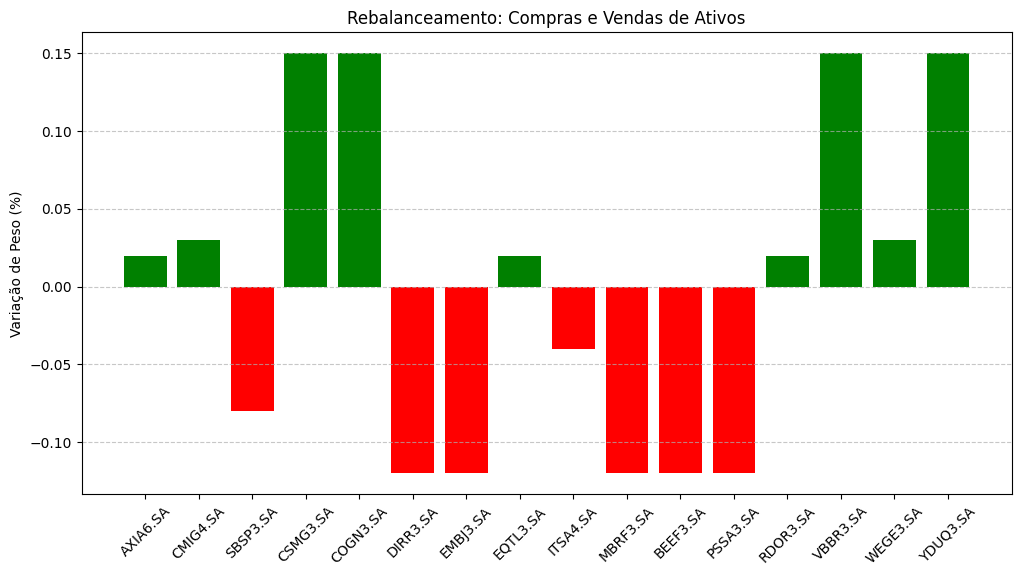

In [83]:
# Extrair os valores de compra e venda do model_B
mudancas_compra = []
mudancas_venda = []
mudancas = []
for a in range(len(dados_retorno_2024.columns)):
    c = pyo.value(model_B.compra[a])
    v = pyo.value(model_B.venda[a])
   
    mudancas.append(c if c > 0.00001 else -v)

    
    # Se comprou, valor positivo; se vendeu, valor negativo
    mudancas_compra.append(c)
    mudancas_venda.append(v)

x_peso_final = []
y_ativado_final = []

for a in range(len(dados_retorno_2024.columns)):
    lista_x = pyo.value(model_B.x[a])
    lista_y = pyo.value(model_B.y[a])

    x_peso_final.append(lista_x)
    y_ativado_final.append(lista_y)
    
lista_peso_anterior = df_final['peso_ativo'].tolist()
df_mudancas = pd.DataFrame({'Ativo': dados_retorno_2024.columns,'Mudança': mudancas, 'Mudança_Compra': mudancas_compra,"Mudança_venda":mudancas_venda,'Ativado':y_ativado_final, "Peso_otimizado":x_peso_final})
# carteira_final['peso_anterior'] = lista_peso_anterior

df_mudancas2 = df_mudancas[df_mudancas['Mudança'].abs() > 0.0001] # Filtrar apenas o que mudou
carteira_final = df_mudancas[df_mudancas['Ativado']>0.5]


plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in df_mudancas2['Mudança']]
plt.bar(df_mudancas2['Ativo'], df_mudancas2['Mudança'], color=colors)
plt.xticks(rotation=45)
plt.title('Rebalanceamento: Compras e Vendas de Ativos')
plt.ylabel('Variação de Peso (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [84]:
carteira_final

,Ativo,Mudança,Mudança_Compra,Mudança_venda,Ativado,Peso_otimizado
3,AXIA6.SA,0.02,0.02,0.00,1.0,0.02
9,CMIG4.SA,0.03,0.03,0.00,1.0,0.15
11,SBSP3.SA,-0.08,0.00,0.08,1.0,0.04
12,CSMG3.SA,0.15,0.15,0.00,1.0,0.15
14,COGN3.SA,0.15,0.15,0.00,1.0,0.15
23,EQTL3.SA,0.02,0.02,0.00,1.0,0.02
46,RDOR3.SA,0.02,0.02,0.00,1.0,0.02
58,VBBR3.SA,0.15,0.15,0.00,1.0,0.15
60,WEGE3.SA,0.03,0.03,0.00,1.0,0.15
61,YDUQ3.SA,0.15,0.15,0.00,1.0,0.15


In [103]:
print(len(df_final))
print(df_final)
print(df_mudancas2)
print(carteira_final)
print(len(carteira_final))

10
          peso_ativo  ativado
CMIG4.SA        0.15      1.0
SBSP3.SA        0.15      1.0
CPFE3.SA        0.02      1.0
DIRR3.SA        0.02      1.0
EMBJ3.SA        0.15      1.0
ITSA4.SA        0.02      1.0
MBRF3.SA        0.15      1.0
BEEF3.SA        0.04      1.0
PSSA3.SA        0.15      1.0
WEGE3.SA        0.15      1.0
       Ativo  Mudança  Mudança_Compra  Mudança_venda  Ativado  Peso_otimizado
3   AXIA6.SA     0.02            0.02           0.00      1.0            0.02
9   CMIG4.SA     0.03            0.03           0.00      1.0            0.15
11  SBSP3.SA    -0.08            0.00           0.08      1.0            0.04
12  CSMG3.SA     0.15            0.15           0.00      1.0            0.15
14  COGN3.SA     0.15            0.15           0.00      1.0            0.15
18  DIRR3.SA    -0.12            0.00           0.12      0.0            0.00
19  EMBJ3.SA    -0.12            0.00           0.12      0.0            0.00
23  EQTL3.SA     0.02            0.02      

In [18]:
carteira_final.shape

(9, 6)

C:\Users\joaon\AppData\Local\Temp\ipykernel_19148\3952749297.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texto = f"Ano 2025\nCarteira Otimizada 2 (Rebalanceada): {acum_otimizado2[-1]:.2f}\nCarteira Otimizada 1: {acum_otimizado1[-1]:.2f}\nIbovespa: {acum_ibov2[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados2)}"


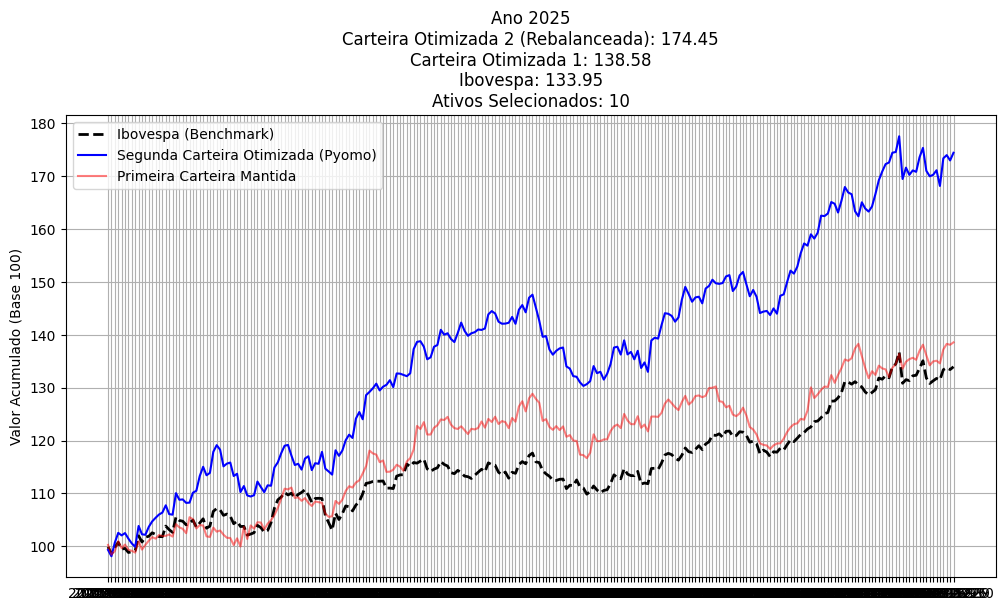

In [105]:
carteira_final2 = carteira_final['Peso_otimizado'].reset_index().drop(columns=['index']).set_index(carteira_final['Ativo'])
ativos_selecionados2 = carteira_final['Ativo'].tolist()
retornos_carteira2 = dados_retorno_2025[ativos_selecionados2]
carteira_otimizada2 = 1 + (retornos_carteira2*carteira_final2['Peso_otimizado']).sum(axis=1)

ativos_carteira_primeira = df_final.index
retornos_carteira_primeira = dados_retorno_2025[ativos_carteira_primeira]
carteira_primeira = 1 +(retornos_carteira_primeira*df_final['peso_ativo']).sum(axis=1)

# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado2 = (carteira_otimizada2).cumprod() *100
acum_otimizado1 = (carteira_primeira).cumprod() *100
# acum_equi = (carteira_equi).cumprod() * 100
acum_ibov2 = (1 + dados_retorno_ibov_2025).cumprod() * 100

# print(acum_otimizado2[-1])
# # print(acum_equi[-1])
# print(acum_ibov2[-1])

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov2, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado2, label='Segunda Carteira Otimizada (Pyomo)', color='blue')
plt.plot(acum_otimizado1, label='Primeira Carteira Mantida', color='red', alpha=0.5)

# texto_titulo = f'Comparação de Performance: Index Tracking ({tamanho_carteira_final} ativos)'
texto = f"Ano 2025\nCarteira Otimizada 2 (Rebalanceada): {acum_otimizado2[-1]:.2f}\nCarteira Otimizada 1: {acum_otimizado1[-1]:.2f}\nIbovespa: {acum_ibov2[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados2)}"

plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()

### ==========================================
### Usar Pietroski 
### ==========================================

In [87]:
score_2023_ativos_pietroski = {}
i=0
for ticker in df_mf_2023['ticker'].unique():
    
    df_temp = df_mf_2023[df_mf_2023['ticker'] == ticker]
    # print(df_temp[['dt_refer', 'earnings_yield', 'ROIC']])
    score_anual = (0.25*df_temp['ROA']+0.25*df_temp['margem_liq'] + 0.25*df_temp['giro_ativo'] + 0.25*df_temp['alavancagem']).sum()
    score_2023_ativos_pietroski[i] = score_anual
    i=i+1


# ------ CRIAÇÃO DO MODELO
model_pietroski_1 = pyo.ConcreteModel()

#variavel x para peso, y para cardinalidade

#--------------------
model_pietroski_1.nome_ativos = pyo.Set(initialize = dados_retorno_2024.columns)
model_pietroski_1.ativos = pyo.RangeSet(0, len(dados_retorno_2024.columns)-1)
model_pietroski_1.dias = pyo.RangeSet(0, len(dados_retorno_2024)-1)
model_pietroski_1.retornos_ativos = pyo.Param(model_pietroski_1.dias, model_pietroski_1.ativos, initialize=lambda model,dia, ativo: dados_retorno_2024.iloc[dia, ativo])    
# model_pietroski_1.retornos_ibov = pyo.Param(model_pietroski_1.dias, initialize=lambda model,dia: dados_retorno_2024['IBOV'].iloc[dia])
model_pietroski_1.theta = pyo.Param(initialize=vb_theta)

#Score do ano anterior utilizado pra frente
model_pietroski_1.score = pyo.Param(model_pietroski_1.ativos, initialize=lambda model, ativo: score_2023_ativos_pietroski[ativo])

model_pietroski_1.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model_pietroski_1.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model_pietroski_1.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model_pietroski_1.peso_minimo = pyo.Param(initialize=vb_peso_minimo)

model_pietroski_1.x = pyo.Var(model_pietroski_1.ativos, bounds=(0,1))
model_pietroski_1.y = pyo.Var(model_pietroski_1.ativos, within=pyo.Binary)

# # Teste, tentar fazer o modelo descobrir melhor quantidade de ativos na carteira.
# model_pietroski_1.card_valor = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(vb_cardinalidade_min, vb_cardinalidade_max))

# Definindo função objetivo
# a ideia na primeira parte é reduzir o erro quadrático
def func_objetivo_1(model):

    retorno_esperado = sum((sum(model_pietroski_1.retornos_ativos[dia, a] * model_pietroski_1.x[a] for a in model_pietroski_1.ativos)) for dia in model_pietroski_1.dias) 

    score_total = model_pietroski_1.theta * sum(model_pietroski_1.x[a] * model_pietroski_1.score[a]  for a in model_pietroski_1.ativos)

    # custo_cardinalidade = model_pietroski_1.card_valor * 5
    
    return retorno_esperado + score_total 

model_pietroski_1.obj1 = pyo.Objective(rule=func_objetivo_1, sense=pyo.maximize)

print('-----Model COnstruído-----')


#REstricao 1 x só ativa se y = 1
def restr_vinculo_x_y(model, a):
    return model_pietroski_1.x[a] <= model_pietroski_1.y[a]
model_pietroski_1.const_restr_vinculo_x_y = pyo.Constraint(model_pietroski_1.ativos, rule=restr_vinculo_x_y)

#peso maximo por acao
def rule_peso_maximo(model, a):
    # return model.x[a] <= 1/model.cardinalidade_valor
    return model_pietroski_1.x[a] <= model_pietroski_1.peso_maximo

model_pietroski_1.const_peso_maximo = pyo.Constraint(model_pietroski_1.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model, a):
    return model_pietroski_1.x[a] >= model_pietroski_1.peso_minimo * model_pietroski_1.y[a]  # se y=1, então x >= 0.05
model_pietroski_1.const_peso_minimo = pyo.Constraint(model_pietroski_1.ativos, rule=rule_peso_minimo)

#Restrição 2 soma peso 1
def soma_peso_1(model):
    return sum(model_pietroski_1.x[a] for a in model_pietroski_1.ativos) == 1
model_pietroski_1.const_soma_peso_1 = pyo.Constraint(rule=soma_peso_1)

# Restrição 3 de cardinalidade, quantidade de ativos no total
def cardinalidade_max(model):
    return sum(
        model_pietroski_1.y[a] for a in model_pietroski_1.ativos
        ) <= model_pietroski_1.cardinalidade_valor_max
model_pietroski_1.const_cardinalidade_total_max = pyo.Constraint(rule=cardinalidade_max)

def cardinalidade_min(model):
    return sum(
        model_pietroski_1.y[a] for a in model_pietroski_1.ativos
        ) >= model_pietroski_1.cardinalidade_valor_min
model_pietroski_1.const_cardinalidade_total_min = pyo.Constraint(rule=cardinalidade_min)




opt = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
# opt.options['TimeLimit'] = 60
resultado = opt.solve(model_pietroski_1, tee=True)
print("-------FIM----------")

-----Model COnstruído-----

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmpyag6cpri.cplex.log' open.
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmp0u8nkuyd.pyomo.lp' read.
Read time = 0.00 sec. (0.01 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmp0u8nkuyd.pyomo.lp
Objective sense      : Maximize
Variables            :     124  [Box: 62,  Binary: 62]
Objective nonzeros   :      62
Linear constraints   :     189  [Less: 187,  Greater: 1,  Equal: 1]
  Nonzeros           :     496
  RHS nonzeros       :      65

Variables            : Min LB: 0.000000         Max UB: 1.00000

In [88]:
lista_grande_pietroski_1 = []
for numero in range(len(dados_retorno_2024.columns)):
    peso_ativo = pyo.value(model_pietroski_1.x[numero])
    ativado = pyo.value(model_pietroski_1.y[numero])
    
    lista_pietroski_1 = [peso_ativo, ativado]
    lista_grande_pietroski_1.append(lista_pietroski_1)
print(lista_grande_pietroski_1)
print(vb_cardinalidade_min)
print(vb_cardinalidade_max)
# print('cardinalidade escolhida: ',pyo.value(model_pietroski_1.card_valor))

final_pietroski_1 = pd.DataFrame(lista_grande_pietroski_1, columns=["peso_ativo","ativado"], index=dados_retorno_2024.columns)
print(len(final_pietroski_1[final_pietroski_1['ativado']!=0]))
print(final_pietroski_1[final_pietroski_1['ativado']!=0])

[[0.15, 1.0], [0.0, 0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.02, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, -0.0], [0.039999999999999813, 1.0], [0.02, 1.0], [0.15000000000000002, 1.0], [0.02, 1.0], [0.0, -0.0], [0.0, 0.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.15000000000000002, 1.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.15000000000000002, 1.0], [0.0, -0.0], [0.0, 0.0]]
10
30
10
           peso_ativo  ativado
ALOS3.SA         0.15      1.0
ITSA4.SA         0.15      1.0
KLBN11.SA        0.02      1.0
M

           peso_ativo  ativado
ALOS3.SA         0.15      1.0
ITSA4.SA         0.15      1.0
KLBN11.SA        0.02      1.0
MBRF3.SA         0.04      1.0
GOAU4.SA         0.02      1.0
BEEF3.SA         0.15      1.0
MOTV3.SA         0.02      1.0
PETR3.SA         0.15      1.0
USIM5.SA         0.15      1.0
VIVA3.SA         0.15      1.0
85.38267942487244


C:\Users\joaon\AppData\Local\Temp\ipykernel_19148\38433640.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_otimizado[-1])
C:\Users\joaon\AppData\Local\Temp\ipykernel_19148\38433640.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texto = f"Carteira Otimizada: {acum_otimizado[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}"


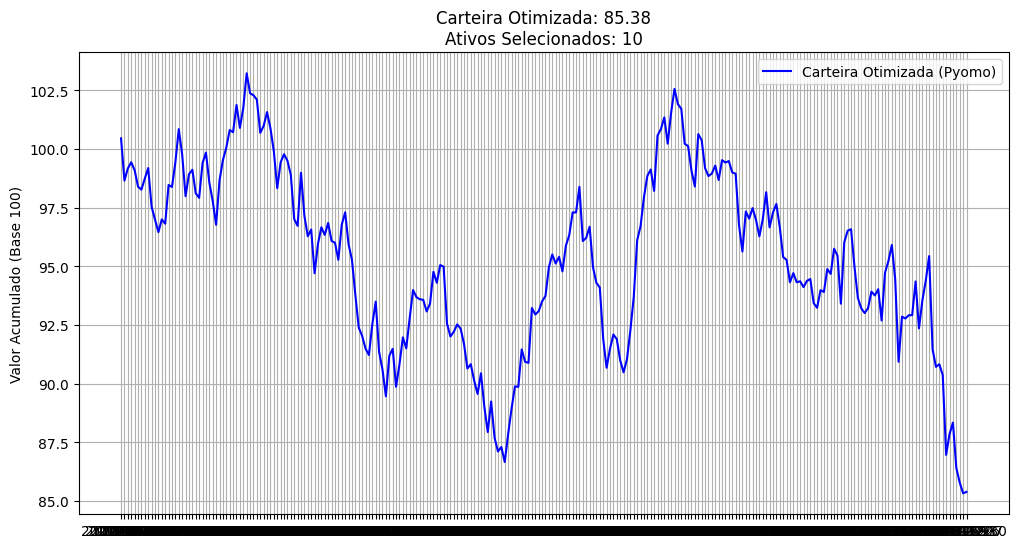

In [89]:
df_final_pietroski_1 = final_pietroski_1[final_pietroski_1['ativado']!=0]
print(df_final_pietroski_1.head(20))
ativos_selecionados = df_final_pietroski_1.index
retornos_carteira= dados_retorno_2024[ativos_selecionados]

carteira_otimizada = (retornos_carteira*df_final_pietroski_1['peso_ativo']).sum(axis=1)
carteira_otimizada = 1 + carteira_otimizada

# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado = (carteira_otimizada).cumprod() * 100
# acum_equi = (carteira_equi).cumprod() * 100
# acum_ibov = (1 + retornos_ibov_primeira_metade['IBOV']).cumprod() * 100

print(acum_otimizado[-1])
# print(acum_equi[-1])
# print(acum_ibov[-1])

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
# plt.plot(acum_ibov, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado, label='Carteira Otimizada (Pyomo)', color='blue')
# plt.plot(acum_equi, label='Carteira Equiponderada', color='red', alpha=0.5)

texto = f"Carteira Otimizada: {acum_otimizado[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}"
# plt.title('Comparação de Performance: Index Tracking (10 ativos)')
plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()

### -------- 2º parte -  REBALANCEAMENTO

In [90]:
pesos_anteriores_pietroski_1 = {a: pyo.value(model_pietroski_1.x[a]) for a in model_pietroski_1.ativos}
pesos_anteriores_pietroski_1

{0: 0.15,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.0,
 5: 0.0,
 6: 0.0,
 7: 0.0,
 8: 0.0,
 9: 0.0,
 10: 0.0,
 11: 0.0,
 12: 0.0,
 13: 0.0,
 14: 0.0,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.0,
 21: 0.0,
 22: 0.0,
 23: 0.0,
 24: 0.0,
 25: 0.0,
 26: 0.0,
 27: 0.0,
 28: 0.0,
 29: 0.0,
 30: 0.15000000000000002,
 31: 0.02,
 32: 0.0,
 33: 0.0,
 34: 0.0,
 35: 0.039999999999999813,
 36: 0.02,
 37: 0.15000000000000002,
 38: 0.02,
 39: 0.0,
 40: 0.0,
 41: 0.0,
 42: 0.15000000000000002,
 43: 0.0,
 44: 0.0,
 45: 0.0,
 46: 0.0,
 47: 0.0,
 48: 0.0,
 49: 0.0,
 50: 0.0,
 51: 0.0,
 52: 0.0,
 53: 0.0,
 54: 0.0,
 55: 0.15000000000000002,
 56: 0.0,
 57: 0.0,
 58: 0.0,
 59: 0.15000000000000002,
 60: 0.0,
 61: 0.0}

In [99]:
score_2024_ativos_pietroski_2 = {}
i=0
for ticker in df_mf_2024['ticker'].unique():
    
    df_temp = df_mf_2024[df_mf_2024['ticker'] == ticker]
    # print(df_temp[['dt_refer', 'earnings_yield', 'ROIC']])
    score_anual = (0.25*df_temp['ROA']+0.25*df_temp['margem_liq'] + 0.25*df_temp['giro_ativo'] + 0.25*df_temp['alavancagem']).sum()
    score_2024_ativos_pietroski_2[i] = score_anual
    i=i+1
import math

# score_2024_ativos_pietroski_2
clean_dict = {k: v if math.isfinite(v) else 0 for k, v in score_2024_ativos_pietroski_2.items()}

score_2024_ativos_pietroski_2= clean_dict

## a ideia aqui é Compra e Venda ,
## mas nao binária, ou seja, nao é 0 nao compra e 1 compra,
# é porcentagem, o quanto comprar e o quanto vender , envolvende uma custo de transação

#criando modelo novo
model_B_pietroski_2 = pyo.ConcreteModel()

model_B_pietroski_2.ativos = pyo.RangeSet(0, len(dados_retorno_2025.columns)-1)
model_B_pietroski_2.dias = pyo.RangeSet(0, len(dados_retorno_2025)-1)
model_B_pietroski_2.ATIVOS_SEGUNDA_METADE = pyo.Param(model_B_pietroski_2.dias, model_B_pietroski_2.ativos,initialize=lambda model,dia, ativo: dados_retorno_2025.iloc[dia, ativo])
# model_B_pietroski_2.IBOV_SEGUNDA_METADE = pyo.Param(model_B_pietroski_2.dias, initialize = lambda model_B_pietroski_2,dia: retornos_ibov_segunda_metade['IBOV'].iloc[dia])

#como se fosse o problema da lista de saber o Quanto a empresa deve produzir e o Quanto a empresa deve comprar o produto de outra

#Definindo variáveis de compra e venda, que serão as usadas
model_B_pietroski_2.x = pyo.Var(model_B_pietroski_2.ativos, bounds=(0,1)) #novos pesos 
model_B_pietroski_2.y = pyo.Var(model_B_pietroski_2.ativos, within=pyo.Binary) #nova cardinalidade 
model_B_pietroski_2.compra =pyo.Var(model_B_pietroski_2.ativos, bounds=(0,1))
model_B_pietroski_2.venda =pyo.Var(model_B_pietroski_2.ativos, bounds=(0,1))
custo_taxa = 0.0003 # = 0.03%


model_B_pietroski_2.theta = pyo.Param(initialize=vb_theta)
model_B_pietroski_2.score = pyo.Param(model_B_pietroski_2.ativos, initialize=lambda model, ativo: score_2024_ativos_pietroski_2[ativo])
model_B_pietroski_2.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model_B_pietroski_2.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model_B_pietroski_2.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model_B_pietroski_2.peso_minimo = pyo.Param(initialize=vb_peso_minimo)

#OBJETIVO
def func_objetivo_2(model_B_pietroski_2):
    #como se trata de 2 momentos, o tracking e o custo de transação
    retorno_fundamentalista = sum((sum(model_B_pietroski_2.ATIVOS_SEGUNDA_METADE[dia, ativo] * model_B_pietroski_2.x[ativo] for ativo in model_B_pietroski_2.ativos)) for dia in model_B_pietroski_2.dias) + model_B_pietroski_2.theta * sum(
        model_B_pietroski_2.x[ativo]  * model_B_pietroski_2.score[ativo] for ativo in model_B_pietroski_2.ativos
    )
    
    score_total = model_B_pietroski_2.theta * sum(model_B_pietroski_2.x[a] * model_B_pietroski_2.score[a]  for a in model_B_pietroski_2.ativos)


    # Custo = taxa × (volume comprado + volume vendido)
    custo_transacao = sum(model_B_pietroski_2.compra[ativo] + model_B_pietroski_2.venda[ativo] for ativo in model_B_pietroski_2.ativos) * custo_taxa

    return retorno_fundamentalista + score_total - custo_transacao
    # return retorno_fundamentalista

model_B_pietroski_2.obj = pyo.Objective(rule=func_objetivo_2, sense=pyo.maximize)

#Restrições
#mais importante se a compra e venda será usada

def regra_equilibrio(model_B_pietroski_2, ativo):
    return model_B_pietroski_2.x[ativo] == pesos_anteriores_pietroski_1[ativo] + model_B_pietroski_2.compra[ativo] - model_B_pietroski_2.venda[ativo]

model_B_pietroski_2.regra_equilibrio = pyo.Constraint(model_B_pietroski_2.ativos, rule=regra_equilibrio)

#restrições de soma peso 1 ; de x só ser ativado se y = 1 ; de cardinalidade 15 para y

def model_B_soma_peso_1(model_B_pietroski_2):
    return sum(
        model_B_pietroski_2.x[ativo] for ativo in model_B_pietroski_2.ativos
    ) == 1
model_B_pietroski_2.model_B_soma_peso_1 = pyo.Constraint( rule=model_B_soma_peso_1)

def model_B_y_cardinalidade_max(model_B_pietroski_2):
    return sum(
        model_B_pietroski_2.y[ativo] for ativo in model_B_pietroski_2.ativos
    ) <= model_B_pietroski_2.cardinalidade_valor_max
model_B_pietroski_2.model_B_y_cardinalidade_total_max = pyo.Constraint(rule = model_B_y_cardinalidade_max)

def model_B_y_cardinalidade_min(model_B_pietroski_2):
    return sum(
        model_B_pietroski_2.y[ativo] for ativo in model_B_pietroski_2.ativos
    ) >= model_B_pietroski_2.cardinalidade_valor_min
model_B_pietroski_2.model_B_y_cardinalidade_total_min = pyo.Constraint(rule = model_B_y_cardinalidade_min)

def model_B_x_y(model_B_pietroski_2, ativo):
    return model_B_pietroski_2.x[ativo] <= model_B_pietroski_2.y[ativo]
model_B_pietroski_2.model_B_x_y = pyo.Constraint(model_B_pietroski_2.ativos, rule = model_B_x_y)

#peso maximo por acao
def rule_peso_maximo(model_B_pietroski_2, a):
    # return model_B_pietroski_2.x[a] <= 1/model_B_pietroski_2.cardinalidade_valor
    return model_B_pietroski_2.x[a] <= model_B_pietroski_2.peso_maximo

model_B_pietroski_2.const_peso_maximo = pyo.Constraint(model_B_pietroski_2.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model_B_pietroski_2, a):
    return model_B_pietroski_2.x[a] >= model_B_pietroski_2.peso_minimo * model_B_pietroski_2.y[a]  # se y=1, então x >= 0.05
model_B_pietroski_2.const_peso_minimo = pyo.Constraint(model_B_pietroski_2.ativos, rule=rule_peso_minimo)

def compra_ou_venda(model_B_pietroski_2, ativo):
    """Um ativo ou é comprado OU vendido, nunca os dois"""
    return model_B_pietroski_2.compra[ativo] + model_B_pietroski_2.venda[ativo] <= 1

model_B_pietroski_2.compra_ou_venda = pyo.Constraint(model_B_pietroski_2.ativos, rule=compra_ou_venda)

# def model_B_y_desativa_se_x_zero(model_B_pietroski_2, ativo):
#     """
#     Se x é pequeno (< peso_minimo), força y=0
#     Equivalente a: y <= x / peso_minimo
#     """
#     return model_B_pietroski_2.y[ativo] <= model_B_pietroski_2.x[ativo] / (model_B_pietroski_2.peso_minimo + 0.00001)

# model_B_pietroski_2.const_y_desativa = pyo.Constraint(model_B_pietroski_2.ativos, rule=model_B_pietroski_2_y_desativa_se_x_zero)



opt_B = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
opt_B.options['TimeLimit'] = 300
resultado = opt_B.solve(model_B_pietroski_2)



resultado = opt_B.solve(model_B_pietroski_2, tee=True)
print(f"\nStatus: {resultado.solver.status}")
print(f"Termination: {resultado.solver.termination_condition}")
print("-------FIM----------")


Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmppupepjod.cplex.log' open.
CPLEX> New value for time limit in seconds: 300
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmph8j9g1wi.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmph8j9g1wi.pyomo.lp
Objective sense      : Maximize
Variables            :     248  [Box: 186,  Binary: 62]
Objective nonzeros   :     186
Linear constraints   :     313  [Less: 249,  Greater: 1,  Equal: 63]
  Nonzeros           :     806
  RHS nonzeros       :     137

Variables            : Min LB: 0.000000 

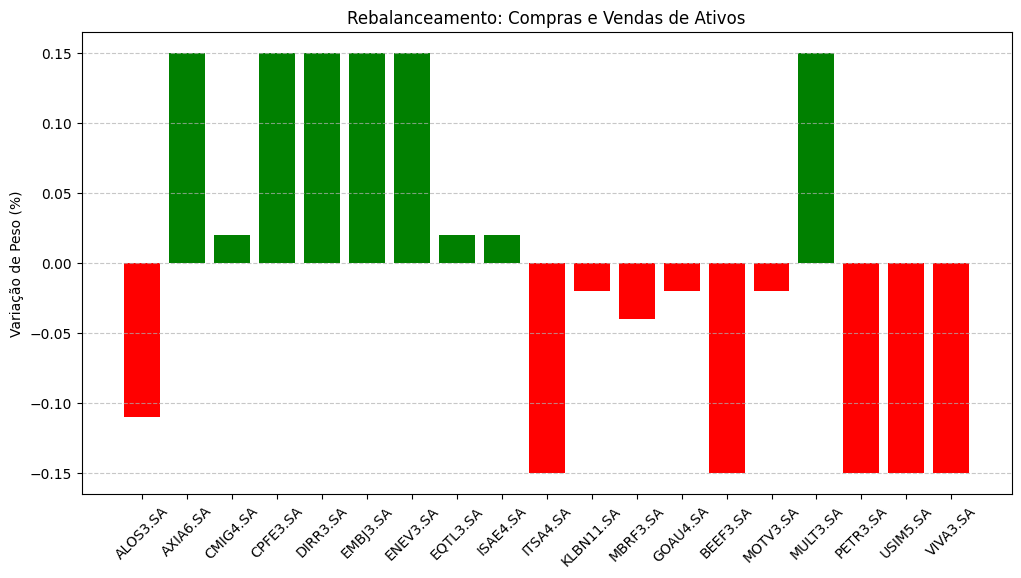

In [101]:
# Extrair os valores de compra e venda do model_B
mudancas_compra_pietroski_2 = []
mudancas_venda_pietroski_2 = []
mudancas_pietroski_2 = []
for a in range(len(dados_retorno_2024.columns)):
    c = pyo.value(model_B_pietroski_2.compra[a])
    v = pyo.value(model_B_pietroski_2.venda[a])
   
    mudancas_pietroski_2.append(c if c > 0.00001 else -v)

    
    # Se comprou, valor positivo; se vendeu, valor negativo
    mudancas_compra_pietroski_2.append(c)
    mudancas_venda_pietroski_2.append(v)

x_peso_final_pietroski_2 = []
y_ativado_final_pietroski_2 = []

for a in range(len(dados_retorno_2024.columns)):
    lista_x = pyo.value(model_B_pietroski_2.x[a])
    lista_y = pyo.value(model_B_pietroski_2.y[a])

    x_peso_final_pietroski_2.append(lista_x)
    y_ativado_final_pietroski_2.append(lista_y)
    
lista_peso_anterior_pietroski_1 = df_final_pietroski_1['peso_ativo'].tolist()
df_mudancas_pietroski_2 = pd.DataFrame({'Ativo': dados_retorno_2024.columns,'Mudança': mudancas_pietroski_2, 'Mudança_Compra': mudancas_compra_pietroski_2,"Mudança_venda":mudancas_venda_pietroski_2,'Ativado':y_ativado_final_pietroski_2, "Peso_otimizado":x_peso_final_pietroski_2})
# carteira_final['peso_anterior'] = lista_peso_anterior

df_mudancas2_final_pietroski_2 = df_mudancas_pietroski_2[df_mudancas_pietroski_2['Mudança'].abs() > 0.0001] # Filtrar apenas o que mudou
carteira_final_pietroski_2 = df_mudancas_pietroski_2[df_mudancas_pietroski_2['Ativado']>0.5]


plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in df_mudancas2_final_pietroski_2['Mudança']]
plt.bar(df_mudancas2_final_pietroski_2['Ativo'], df_mudancas2_final_pietroski_2['Mudança'], color=colors)
plt.xticks(rotation=45)
plt.title('Rebalanceamento: Compras e Vendas de Ativos')
plt.ylabel('Variação de Peso (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [102]:
carteira_final_pietroski_2

,Ativo,Mudança,Mudança_Compra,Mudança_venda,Ativado,Peso_otimizado
0,ALOS3.SA,-0.11,0.00,0.11,1.0,0.04
3,AXIA6.SA,0.15,0.15,0.00,1.0,0.15
9,CMIG4.SA,0.02,0.02,0.00,1.0,0.02
16,CPFE3.SA,0.15,0.15,0.00,1.0,0.15
18,DIRR3.SA,0.15,0.15,0.00,1.0,0.15
19,EMBJ3.SA,0.15,0.15,0.00,1.0,0.15
21,ENEV3.SA,0.15,0.15,0.00,1.0,0.15
23,EQTL3.SA,0.02,0.02,0.00,1.0,0.02
29,ISAE4.SA,0.02,0.02,0.00,1.0,0.02
40,MULT3.SA,0.15,0.15,0.00,1.0,0.15


In [104]:
print(len(df_final_pietroski_1))
print(df_final_pietroski_1)
print(df_mudancas2_final_pietroski_2)
print(carteira_final_pietroski_2)
print(len(carteira_final_pietroski_2))

10
           peso_ativo  ativado
ALOS3.SA         0.15      1.0
ITSA4.SA         0.15      1.0
KLBN11.SA        0.02      1.0
MBRF3.SA         0.04      1.0
GOAU4.SA         0.02      1.0
BEEF3.SA         0.15      1.0
MOTV3.SA         0.02      1.0
PETR3.SA         0.15      1.0
USIM5.SA         0.15      1.0
VIVA3.SA         0.15      1.0
        Ativo  Mudança  Mudança_Compra  Mudança_venda  Ativado  Peso_otimizado
0    ALOS3.SA    -0.11            0.00           0.11      1.0            0.04
3    AXIA6.SA     0.15            0.15           0.00      1.0            0.15
9    CMIG4.SA     0.02            0.02           0.00      1.0            0.02
16   CPFE3.SA     0.15            0.15           0.00      1.0            0.15
18   DIRR3.SA     0.15            0.15           0.00      1.0            0.15
19   EMBJ3.SA     0.15            0.15           0.00      1.0            0.15
21   ENEV3.SA     0.15            0.15           0.00      1.0            0.15
23   EQTL3.SA     0.02  

C:\Users\joaon\AppData\Local\Temp\ipykernel_19148\2939439263.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texto = f"Ano 2025\nCarteira Otimizada 2 (Rebalanceada): {acum_otimizado2[-1]:.2f}\nCarteira Otimizada 1: {acum_otimizado1[-1]:.2f}\nIbovespa: {acum_ibov2[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados2)}"


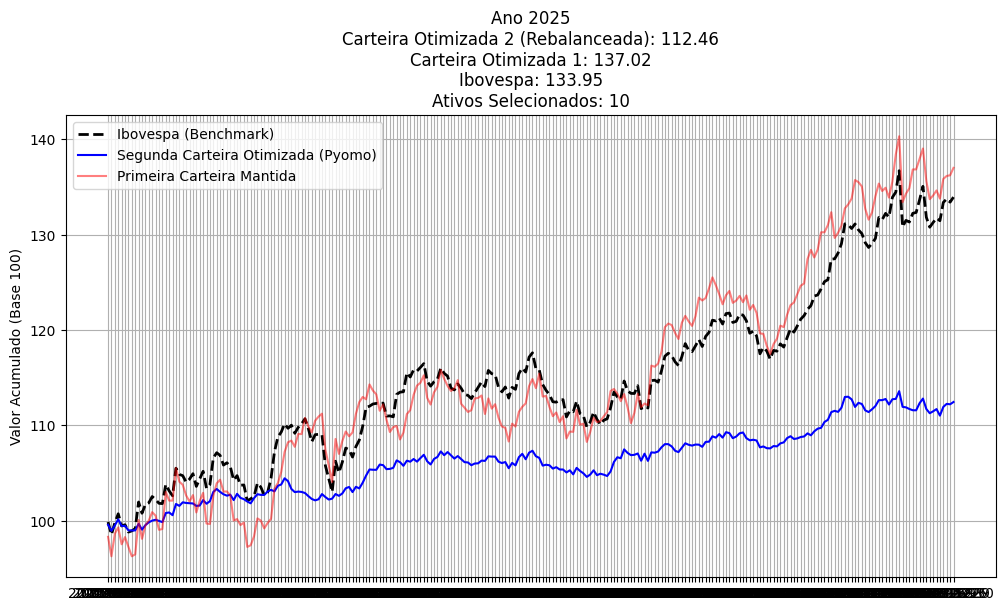

In [106]:
carteira_final2_pietroski_2 = carteira_final_pietroski_2['Peso_otimizado'].reset_index().drop(columns=['index']).set_index(carteira_final['Ativo'])
ativos_selecionados2_pietroski_2  = carteira_final_pietroski_2['Ativo'].tolist()
retornos_carteira2_pietroski_2  = dados_retorno_2025[ativos_selecionados2_pietroski_2]
carteira_otimizada2_pietroski_2  = 1 + (retornos_carteira2_pietroski_2 *carteira_final2_pietroski_2['Peso_otimizado']).sum(axis=1)

ativos_carteira_primeira = df_final_pietroski_1.index
retornos_carteira_primeira = dados_retorno_2025[ativos_carteira_primeira]
carteira_primeira = 1 +(retornos_carteira_primeira*df_final_pietroski_1['peso_ativo']).sum(axis=1)

# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado2 = (carteira_otimizada2_pietroski_2).cumprod() *100
acum_otimizado1 = (carteira_primeira).cumprod() *100
# acum_equi = (carteira_equi).cumprod() * 100
acum_ibov2 = (1 + dados_retorno_ibov_2025).cumprod() * 100

# print(acum_otimizado2[-1])
# # print(acum_equi[-1])
# print(acum_ibov2[-1])

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov2, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado2, label='Segunda Carteira Otimizada (Pyomo)', color='blue')
plt.plot(acum_otimizado1, label='Primeira Carteira Mantida', color='red', alpha=0.5)

# texto_titulo = f'Comparação de Performance: Index Tracking ({tamanho_carteira_final} ativos)'
texto = f"Ano 2025\nCarteira Otimizada 2 (Rebalanceada): {acum_otimizado2[-1]:.2f}\nCarteira Otimizada 1: {acum_otimizado1[-1]:.2f}\nIbovespa: {acum_ibov2[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados2)}"

plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()